In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import pyspark
from pyspark.sql.functions import col
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, when, regexp_replace, to_date, count, sum as spark_sum, isnan
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

In [5]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

# 4. LMS dataset

In [6]:
attributes_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("sep", ",")
    .csv("./datamart/bronze/lms/bronze_lms_*.csv")
)
attributes_df.printSchema()
print("Row count:", attributes_df.count())

root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- loan_start_date: date (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- installment_num: integer (nullable = true)
 |-- loan_amt: integer (nullable = true)
 |-- due_amt: double (nullable = true)
 |-- paid_amt: double (nullable = true)
 |-- overdue_amt: double (nullable = true)
 |-- balance: double (nullable = true)
 |-- snapshot_date: date (nullable = true)

Row count: 104288


In [7]:
attributes_df.show(5, truncate=False)

+---------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|loan_id              |Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|
+---------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|CUS_0x100b_2024_03_01|CUS_0x100b |2024-03-01     |10    |6              |10000   |1000.0 |1000.0  |0.0        |4000.0 |2024-09-01   |
|CUS_0x1011_2023_11_01|CUS_0x1011 |2023-11-01     |10    |10             |10000   |1000.0 |1000.0  |0.0        |0.0    |2024-09-01   |
|CUS_0x1013_2023_12_01|CUS_0x1013 |2023-12-01     |10    |9              |10000   |1000.0 |1000.0  |0.0        |1000.0 |2024-09-01   |
|CUS_0x1018_2023_11_01|CUS_0x1018 |2023-11-01     |10    |10             |10000   |1000.0 |0.0     |7000.0     |7000.0 |2024-09-01   |
|CUS_0x102d_2024_01_01|CUS_0x102d |2024-01-01     |10  

In [8]:
attributes_df.describe().show(truncate=False)

[Stage 11:=======================>                                 (5 + 7) / 12]

+-------+---------------------+-----------+------+-----------------+--------+-----------------+-----------------+-----------------+------------------+
|summary|loan_id              |Customer_ID|tenure|installment_num  |loan_amt|due_amt          |paid_amt         |overdue_amt      |balance           |
+-------+---------------------+-----------+------+-----------------+--------+-----------------+-----------------+-----------------+------------------+
|count  |104288               |104288     |104288|104288           |104288  |104288           |104288           |104288           |104288            |
|mean   |NULL                 |NULL       |10.0  |4.471684182264498|10000.0 |885.1833384473765|704.4051089291194|747.9575790119669|6276.273396747469 |
|stddev |NULL                 |NULL       |0.0   |3.116240553153162|0.0     |318.8020864755487|492.4535879054297|1828.23156295182 |2960.5296623546014|
|min    |CUS_0x1000_2023_05_01|CUS_0x1000 |10    |0                |10000   |0.0              

### Null check

In [9]:
attributes_df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in attributes_df.columns
]).show()

+-------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|
+-------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|      0|          0|              0|     0|              0|       0|      0|       0|          0|      0|            0|
+-------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+



### Rows per snapshot month

In [10]:
attributes_df.groupBy("snapshot_date").count().orderBy("snapshot_date").show(30)

+-------------+-----+
|snapshot_date|count|
+-------------+-----+
|   2023-01-01|  530|
|   2023-02-01| 1031|
|   2023-03-01| 1537|
|   2023-04-01| 2047|
|   2023-05-01| 2568|
|   2023-06-01| 3085|
|   2023-07-01| 3556|
|   2023-08-01| 4037|
|   2023-09-01| 4491|
|   2023-10-01| 4978|
|   2023-11-01| 5469|
|   2023-12-01| 5428|
|   2024-01-01| 5412|
|   2024-02-01| 5424|
|   2024-03-01| 5425|
|   2024-04-01| 5417|
|   2024-05-01| 5391|
|   2024-06-01| 5418|
|   2024-07-01| 5442|
|   2024-08-01| 5531|
|   2024-09-01| 5537|
|   2024-10-01| 5502|
|   2024-11-01| 5501|
|   2024-12-01| 5531|
+-------------+-----+



### Unique loans and customers

In [11]:
print("Unique loan_id:", attributes_df.select("loan_id").distinct().count())
print("Unique Customer_ID:", attributes_df.select("Customer_ID").distinct().count())

Unique loan_id:     11974


[Stage 26:======================================>                  (8 + 4) / 12]

Unique Customer_ID: 11974


### Installment number distribution (mob proxy)

In [22]:
attributes_df.groupBy("installment_num").count().orderBy("installment_num").show()

+---------------+-----+
|installment_num|count|
+---------------+-----+
|              0|11974|
|              1|11459|
|              2|10971|
|              3|10515|
|              4|10022|
|              5| 9479|
|              6| 8974|
|              7| 8476|
|              8| 7985|
|              9| 7472|
|             10| 6961|
+---------------+-----+



In [13]:
column_type_map = {
    "loan_id":          StringType(),
    "Customer_ID":      StringType(),
    "loan_start_date":  DateType(),
    "tenure":           IntegerType(),
    "installment_num":  IntegerType(),
    "loan_amt":         FloatType(),
    "due_amt":          FloatType(),
    "paid_amt":         FloatType(),
    "overdue_amt":      FloatType(),
    "balance":          FloatType(),
    "snapshot_date":    DateType(),
}
lms_df = attributes_df
for c, t in column_type_map.items():
    lms_df = lms_df.withColumn(c, col(c).cast(t))

lms_df.printSchema()
print("Row count after cast:", lms_df.count())

root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- loan_start_date: date (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- installment_num: integer (nullable = true)
 |-- loan_amt: float (nullable = true)
 |-- due_amt: float (nullable = true)
 |-- paid_amt: float (nullable = true)
 |-- overdue_amt: float (nullable = true)
 |-- balance: float (nullable = true)
 |-- snapshot_date: date (nullable = true)

Row count after cast: 104288


### Loan amount distribution

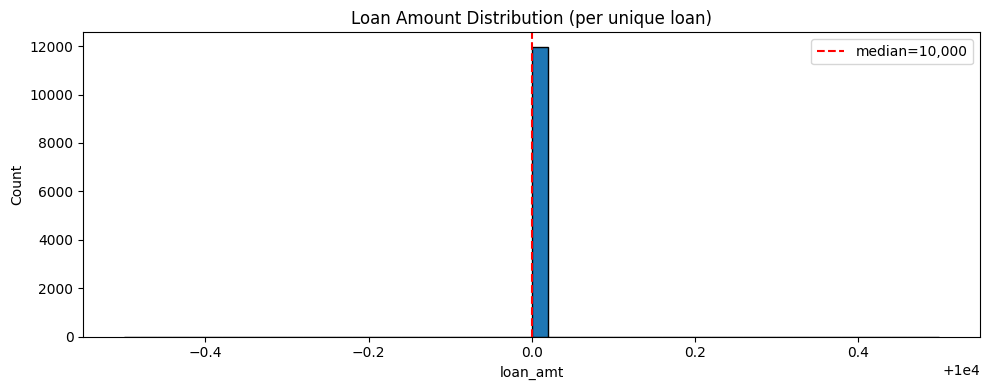

In [14]:
loan_amts = lms_df.select("loan_id", "loan_amt").dropDuplicates(["loan_id"]).toPandas()

plt.figure(figsize=(10, 4))
plt.hist(loan_amts["loan_amt"].dropna(), bins=50, edgecolor="black")
plt.title("Loan Amount Distribution (per unique loan)")
plt.xlabel("loan_amt")
plt.ylabel("Count")
plt.axvline(loan_amts["loan_amt"].median(), color="red", linestyle="--",
            label=f"median={loan_amts['loan_amt'].median():,.0f}")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
lms_silver = lms_df

lms_silver = lms_silver.withColumn("mob", col("installment_num").cast(IntegerType()))

lms_silver = lms_silver.withColumn(
    "installments_missed",
    F.ceil(F.try_divide(col("overdue_amt"), col("due_amt"))).cast(IntegerType()),
).fillna(0)

lms_silver = lms_silver.withColumn(
    "first_missed_date",
    F.when(
        col("installments_missed") > 0,
        F.add_months(col("snapshot_date"), -1 * col("installments_missed")),
    ).cast(DateType()),
)

lms_silver = lms_silver.withColumn(
    "dpd",
    F.when(
        col("overdue_amt") > 0.0,
        F.datediff(col("snapshot_date"), col("first_missed_date")),
    ).otherwise(0).cast(IntegerType()),
)

lms_silver.select("loan_id", "mob", "due_amt", "overdue_amt",
                  "installments_missed", "first_missed_date", "dpd").show(10)

+--------------------+---+-------+-----------+-------------------+-----------------+---+
|             loan_id|mob|due_amt|overdue_amt|installments_missed|first_missed_date|dpd|
+--------------------+---+-------+-----------+-------------------+-----------------+---+
|CUS_0x100b_2024_0...|  6| 1000.0|        0.0|                  0|             NULL|  0|
|CUS_0x1011_2023_1...| 10| 1000.0|        0.0|                  0|             NULL|  0|
|CUS_0x1013_2023_1...|  9| 1000.0|        0.0|                  0|             NULL|  0|
|CUS_0x1018_2023_1...| 10| 1000.0|     7000.0|                  7|       2024-02-01|213|
|CUS_0x102d_2024_0...|  8| 1000.0|        0.0|                  0|             NULL|  0|
|CUS_0x102e_2024_0...|  5| 1000.0|     3000.0|                  3|       2024-06-01| 92|
|CUS_0x1041_2023_1...| 10| 1000.0|        0.0|                  0|             NULL|  0|
|CUS_0x1048_2024_0...|  7| 1000.0|     6000.0|                  6|       2024-03-01|184|
|CUS_0x104a_2023_1...

### DPD distribution (all mobs)

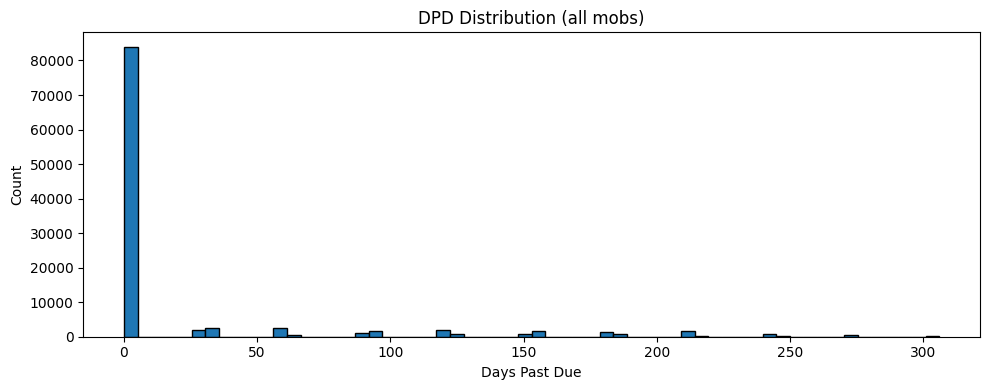

count    104288.000000
mean         22.821696
std          55.784837
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         306.000000
Name: dpd, dtype: float64


In [17]:
dpd_pd = lms_silver.select("dpd").toPandas()

plt.figure(figsize=(10, 4))
plt.hist(dpd_pd["dpd"].dropna(), bins=60, edgecolor="black")
plt.title("DPD Distribution (all mobs)")
plt.xlabel("Days Past Due")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(dpd_pd["dpd"].describe())

In [18]:
MOB = 6
DPD_THRESHOLD = 30

label_df = lms_silver.filter(col("mob") == MOB)
label_df = label_df.withColumn(
    "label",
    F.when(col("dpd") >= DPD_THRESHOLD, 1).otherwise(0).cast(IntegerType()),
)

print(f"Rows at mob={MOB}: {label_df.count():,}")
label_df.select("loan_id", "Customer_ID", "dpd", "label", "snapshot_date").show(10)

Rows at mob=6: 8,974
+--------------------+-----------+---+-----+-------------+
|             loan_id|Customer_ID|dpd|label|snapshot_date|
+--------------------+-----------+---+-----+-------------+
|CUS_0x100b_2024_0...| CUS_0x100b|  0|    0|   2024-09-01|
|CUS_0x1096_2024_0...| CUS_0x1096| 92|    1|   2024-09-01|
|CUS_0x111c_2024_0...| CUS_0x111c|123|    1|   2024-09-01|
|CUS_0x112d_2024_0...| CUS_0x112d| 62|    1|   2024-09-01|
|CUS_0x1204_2024_0...| CUS_0x1204| 62|    1|   2024-09-01|
|CUS_0x12af_2024_0...| CUS_0x12af|  0|    0|   2024-09-01|
|CUS_0x12cb_2024_0...| CUS_0x12cb| 92|    1|   2024-09-01|
|CUS_0x12fc_2024_0...| CUS_0x12fc|  0|    0|   2024-09-01|
|CUS_0x144c_2024_0...| CUS_0x144c|  0|    0|   2024-09-01|
|CUS_0x1546_2024_0...| CUS_0x1546|  0|    0|   2024-09-01|
+--------------------+-----------+---+-----+-------------+
only showing top 10 rows


### Overall label distribution

 label  count       pct
     0   6383 71.127702
     1   2591 28.872298


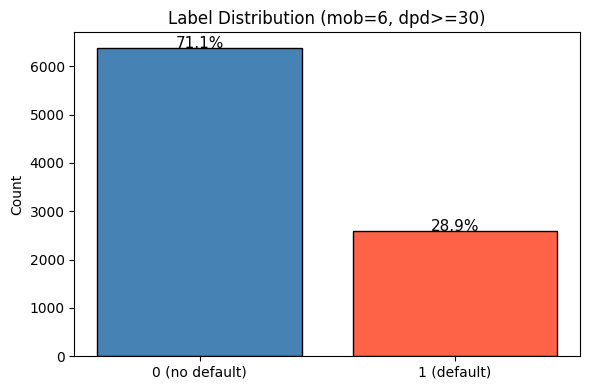

In [19]:
label_counts = label_df.groupBy("label").count().orderBy("label").toPandas()
label_counts["pct"] = label_counts["count"] / label_counts["count"].sum() * 100
print(label_counts.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.bar(["0 (no default)", "1 (default)"], label_counts["count"],
        color=["steelblue", "tomato"], edgecolor="black")
for i, row in label_counts.iterrows():
    plt.text(i, row["count"] + 5, f"{row['pct']:.1f}%", ha="center", fontsize=11)
plt.title(f"Label Distribution (mob={MOB}, dpd>={DPD_THRESHOLD})")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Default rate over time (by snapshot_date)

snapshot_date  total  defaults  default_rate
   2023-07-01    530       140         26.42
   2023-08-01    501       154         30.74
   2023-09-01    506       162         32.02
   2023-10-01    510       137         26.86
   2023-11-01    521       139         26.68
   2023-12-01    517       137         26.50
   2024-01-01    471       140         29.72
   2024-02-01    481       139         28.90
   2024-03-01    454       119         26.21
   2024-04-01    487       125         25.67
   2024-05-01    491       143         29.12
   2024-06-01    489       151         30.88
   2024-07-01    485       144         29.69
   2024-08-01    518       147         28.38
   2024-09-01    511       168         32.88
   2024-10-01    513       142         27.68
   2024-11-01    491       149         30.35
   2024-12-01    498       155         31.12


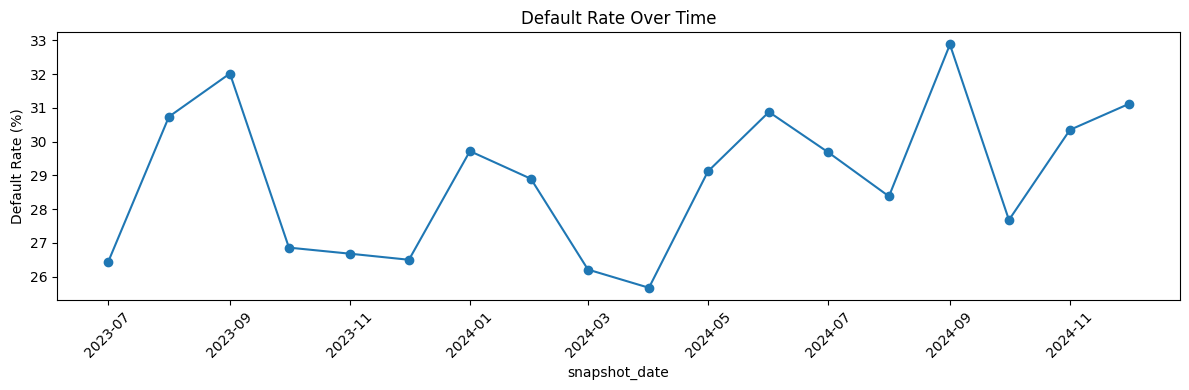

In [20]:
default_by_date = (
    label_df
    .groupBy("snapshot_date")
    .agg(
        F.count("*").alias("total"),
        F.sum("label").alias("defaults"),
    )
    .withColumn("default_rate", F.round(col("defaults") / col("total") * 100, 2))
    .orderBy("snapshot_date")
    .toPandas()
)
print(default_by_date.to_string(index=False))

plt.figure(figsize=(12, 4))
plt.plot(default_by_date["snapshot_date"], default_by_date["default_rate"], marker="o")
plt.title("Default Rate Over Time")
plt.xlabel("snapshot_date")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### DPD distribution at mob=6

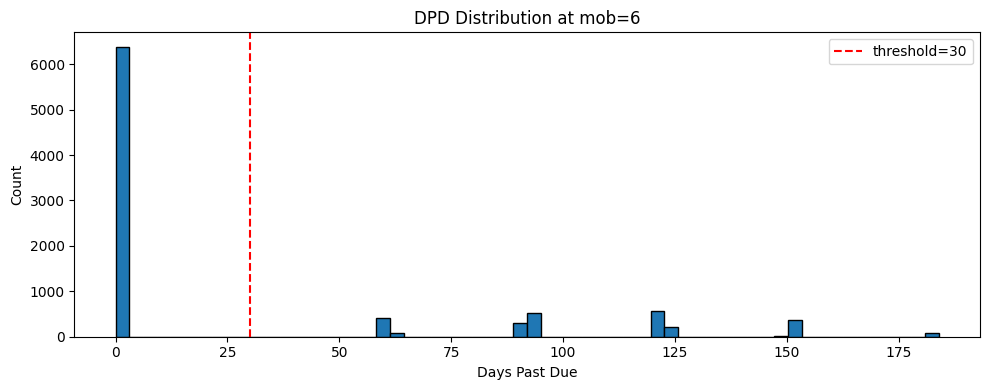

In [21]:
dpd_mob6 = label_df.select("dpd").toPandas()

plt.figure(figsize=(10, 4))
plt.hist(dpd_mob6["dpd"].dropna(), bins=60, edgecolor="black")
plt.axvline(DPD_THRESHOLD, color="red", linestyle="--", label=f"threshold={DPD_THRESHOLD}")
plt.title(f"DPD Distribution at mob={MOB}")
plt.xlabel("Days Past Due")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()